In [2]:
import pandas as pd 

In [3]:
credit_df = pd.read_csv("../Data/creditcard.csv")
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
fraud_df = pd.read_csv("../Data/Fraud_Data.csv")
fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [5]:
ip_df = pd.read_csv("../Data/IpAddress_to_Country.csv")
ip_df.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


## Data Cleaning

### Check for Missing Values and Duplicates

In [6]:
# Check for missing values in all datasets
print("--- Missing Values ---")
print("Fraud Data:\n", fraud_df.isnull().sum(), "\n")
print("Credit Card Data:\n", credit_df.isnull().sum(), "\n")
print("IP to Country Data:\n", ip_df.isnull().sum(), "\n")

# Check for duplicates
print(" Duplicate Rows ")
print(f"Fraud Data Duplicates: {fraud_df.duplicated().sum()}")
print(f"Credit Card Data Duplicates: {credit_df.duplicated().sum()}")
print(f"IP to Country Data Duplicates: {ip_df.duplicated().sum()}")

# Check data types
print("\n Data Types (Fraud Data)")
print(fraud_df.dtypes)

--- Missing Values ---
Fraud Data:
 user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64 

Credit Card Data:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64 

IP to Country Data:
 lower_bound_ip_address    0
upper_bound_ip_address    0
country                   0
dtype: int64 

 Duplicate Rows 
Fraud Data Duplicates: 0
Credit Card Data Duplicates: 1081
IP to Country Data Duplicates: 0

 Data Types (Fraud Data)
user_id             int64
signup_time        object
purchase_time   

### Correcting Data Types and Removing Duplicates

In [7]:
# Convert timestamps to datetime objects
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

# Remove duplicates if any exist
fraud_df = fraud_df.drop_duplicates()
credit_df = credit_df.drop_duplicates()

# Final check of the types and row counts
print("Updated Data Types (Fraud Data)")
print(fraud_df[['signup_time', 'purchase_time']].dtypes)
print(f"\nFraud Data rows after dropping duplicates: {len(fraud_df)}")
print(f"Credit Card Data rows after dropping duplicates: {len(credit_df)}")

Updated Data Types (Fraud Data)
signup_time      datetime64[ns]
purchase_time    datetime64[ns]
dtype: object

Fraud Data rows after dropping duplicates: 151112
Credit Card Data rows after dropping duplicates: 283726


### Class Distribution Analysis

In [8]:
# Calculate distribution for Fraud_Data.csv
fraud_counts = fraud_df['class'].value_counts()
fraud_pct = fraud_df['class'].value_counts(normalize=True) * 100

# Calculate distribution for creditcard.csv
credit_counts = credit_df['Class'].value_counts()
credit_pct = credit_df['Class'].value_counts(normalize=True) * 100

print("Class Distribution: Fraud Data (E-commerce)")
print(f"Non-Fraud (0): {fraud_counts[0]} ({fraud_pct[0]:.2f}%)")
print(f"Fraud (1):     {fraud_counts[1]} ({fraud_pct[1]:.2f}%)\n")

print(" Class Distribution: Credit Card Data (Bank) ")
print(f"Non-Fraud (0): {credit_counts[0]} ({credit_pct[0]:.2f}%)")
print(f"Fraud (1):     {credit_counts[1]} ({credit_pct[1]:.2f}%)")

Class Distribution: Fraud Data (E-commerce)
Non-Fraud (0): 136961 (90.64%)
Fraud (1):     14151 (9.36%)

 Class Distribution: Credit Card Data (Bank) 
Non-Fraud (0): 283253 (99.83%)
Fraud (1):     473 (0.17%)


### IP to Country Mapping

In [9]:
# Ensure IP addresses are integers for comparison
fraud_df['ip_address'] = fraud_df['ip_address'].astype(int)
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype(int)
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype(int)

# To use merge_asof, both dataframes must be sorted by the key
fraud_df = fraud_df.sort_values('ip_address')
ip_df = ip_df.sort_values('lower_bound_ip_address')

# Perform a range-based merge
# This finds the largest lower_bound_ip_address that is less than or equal to the user's ip_address
fraud_merged = pd.merge_asof(
    fraud_df, 
    ip_df, 
    left_on='ip_address', 
    right_on='lower_bound_ip_address'
)

# Crucial step: Check if the IP actually falls within the upper bound of that range
# If it's outside the range, the country should be 'Unknown'
fraud_merged.loc[fraud_merged['ip_address'] > fraud_merged['upper_bound_ip_address'], 'country'] = 'Unknown'

# Fill any remaining NaNs in country with 'Unknown'
fraud_merged['country'] = fraud_merged['country'].fillna('Unknown')

# Check results
print(" Geolocation Integration Summary ")
print(fraud_merged[['ip_address', 'country']].head())
print(f"\nUnique countries found: {fraud_merged['country'].nunique()}")
print(f"Number of 'Unknown' countries: {(fraud_merged['country'] == 'Unknown').sum()}")

 Geolocation Integration Summary 
   ip_address  country
0       52093  Unknown
1       93447  Unknown
2      105818  Unknown
3      117566  Unknown
4      131423  Unknown

Unique countries found: 182
Number of 'Unknown' countries: 21966


### Country Analysis and Time-Based Features

In [10]:
# 1. Analyze fraud patterns by country (Top 10 by fraud count)
country_fraud = fraud_merged.groupby('country')['class'].sum().sort_values(ascending=False).head(10)

# 2. Time-based features
fraud_merged['hour_of_day'] = fraud_merged['purchase_time'].dt.hour
fraud_merged['day_of_week'] = fraud_merged['purchase_time'].dt.dayofweek

# 3. time_since_signup (Duration in seconds)
fraud_merged['time_since_signup'] = (fraud_merged['purchase_time'] - fraud_merged['signup_time']).dt.total_seconds()

print(" Top 10 Countries by Fraudulent Transactions ")
print(country_fraud)

print("\n Sample of New Time Features ")
print(fraud_merged[['purchase_time', 'signup_time', 'time_since_signup', 'hour_of_day', 'day_of_week']].head())

 Top 10 Countries by Fraudulent Transactions 
country
United States        5551
Unknown              1883
China                1043
Japan                 715
United Kingdom        477
Korea Republic of     380
Canada                348
France                300
Brazil                270
Germany               262
Name: class, dtype: int64

 Sample of New Time Features 
        purchase_time         signup_time  time_since_signup  hour_of_day  \
0 2015-03-08 10:00:39 2015-02-16 00:17:05          1763014.0           10   
1 2015-03-20 17:23:45 2015-03-08 04:03:22          1084823.0           17   
2 2015-05-26 08:54:34 2015-05-17 16:45:54           749320.0            8   
3 2015-05-28 21:09:13 2015-03-03 19:58:39          7434634.0           21   
4 2015-04-05 07:31:46 2015-03-20 00:31:27          1407619.0            7   

   day_of_week  
0            6  
1            4  
2            1  
3            3  
4            6  


### Transaction Frequency and Velocity

In [11]:
# 1. Frequency: Number of transactions per device
fraud_merged['device_count'] = fraud_merged.groupby('device_id')['device_id'].transform('count')

# 2. Frequency: Number of transactions per IP address
fraud_merged['ip_count'] = fraud_merged.groupby('ip_address')['ip_address'].transform('count')

# Display the relationship between frequency and fraud
print("Correlation: Frequency vs Fraud ")
print(fraud_merged[['device_count', 'ip_count', 'class']].corr()['class'])

# Show top velocity offenders
print("\n High Velocity Device Examples ")
print(fraud_merged[fraud_merged['device_count'] > 1][['device_id', 'device_count', 'class']].head())

Correlation: Frequency vs Fraud 
device_count    0.670837
ip_count        0.658622
class           1.000000
Name: class, dtype: float64

 High Velocity Device Examples 
        device_id  device_count  class
41  UCMYUQFHXXHEO             2      0
49  QAIQAXBOKWWYG             2      0
59  UMJXEBLNCNXDG             3      0
65  NTNHHPUOEFYTD             2      0
68  FBHIRVGVKKWAI            16      1


### Encoding and Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

# Select features for the model
# Categorical features to encode
categorical_features = ['source', 'browser', 'sex'] 

# Note: 'country' has 182 categories. 
# For now, let's include it, but we might want to group rare countries later.
categorical_features.append('country')

# Numerical features to scale
numerical_features = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'device_count', 'ip_count']

# One-Hot Encoding
fraud_final = pd.get_dummies(fraud_merged, columns=categorical_features, drop_first=True)

# Scaling Numerical Features
scaler = StandardScaler()
fraud_final[numerical_features] = scaler.fit_transform(fraud_final[numerical_features])

# Also scale the Credit Card data (Time and Amount)
credit_df['Amount'] = scaler.fit_transform(credit_df[['Amount']])
credit_df['Time'] = scaler.fit_transform(credit_df[['Time']])

print("--- Data Transformation Summary ---")
print(f"New shape of Fraud Data after encoding: {fraud_final.shape}")
print("\nScaled Numerical Features (First 5 rows):")
print(fraud_final[numerical_features].head())

--- Data Transformation Summary ---
New shape of Fraud Data after encoding: (151112, 203)

Scaled Numerical Features (First 5 rows):
   purchase_value       age  time_since_signup  hour_of_day  day_of_week  \
0        0.494721  0.331793          -1.013679    -0.220124     1.489476   
1       -0.214781 -0.364448          -1.230613     0.792542     0.492565   
2       -0.214781 -0.132367          -1.337931    -0.509456    -1.002803   
3       -0.214781  0.795954           0.800513     1.371208    -0.005891   
4        0.985915  0.563874          -1.127359    -0.654123     1.489476   

   device_count  ip_count  
0     -0.261514 -0.232162  
1     -0.261514 -0.232162  
2     -0.261514 -0.232162  
3     -0.261514 -0.232162  
4     -0.261514 -0.232162  


### Train-Test Split and SMOTE

In [13]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# Define Features (X) and Target (y)
X = fraud_final.drop(['class', 'user_id', 'device_id', 'signup_time', 'purchase_time'], axis=1)
y = fraud_final['class']

# Fix NaNs: Fill any NaNs introduced during encoding/merging with 0
# Since the data is Scaled (StandardScaler), 0 is the mean of the column.
X = X.fillna(0)

# Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Original training class distribution: {Counter(y_train)}")

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Resampled training class distribution: {Counter(y_train_resampled)}")
print(f"Test set distribution (remains imbalanced): {Counter(y_test)}")

Original training class distribution: Counter({0: 109568, 1: 11321})


/home/kidus/anaconda3/envs/ml_base/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled training class distribution: Counter({0: 109568, 1: 109568})
Test set distribution (remains imbalanced): Counter({0: 27393, 1: 2830})


### Train Logistic Regression as Interpretable Baseline  

--- Logistic Regression Baseline Results ---
AUC-PR Score: 0.0939

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.13      0.22     27393
           1       0.09      0.88      0.17      2830

    accuracy                           0.20     30223
   macro avg       0.50      0.51      0.20     30223
weighted avg       0.84      0.20      0.22     30223



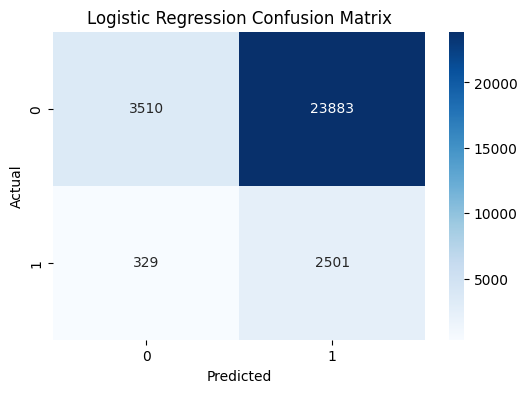

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

# Make Predictions
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

# Calculate AUC-PR
precision, recall, _ = precision_recall_curve(y_test, lr_probs)
auc_pr_lr = auc(recall, precision)

print("Logistic Regression Baseline Results")
print(f"AUC-PR Score: {auc_pr_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

# 4. Confusion Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Ensemble Model using Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# Basic Hyperparameter Tuning (n_estimators and max_depth)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}

# Grid Search with Stratified K-Fold
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

best_rf = grid_search.best_estimator_

# Evaluate Best Random Forest
rf_preds = best_rf.predict(X_test)
rf_probs = best_rf.predict_proba(X_test)[:, 1]

precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_probs)
auc_pr_rf = auc(recall_rf, precision_rf)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Random Forest AUC-PR: {auc_pr_rf:.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_preds))

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Random Forest AUC-PR: 0.6927

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     27393
           1       0.86      0.55      0.67      2830

    accuracy                           0.95     30223
   macro avg       0.91      0.77      0.82     30223
weighted avg       0.95      0.95      0.94     30223



### Stratified 5-Fold Cross-Validation

In [21]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Initialize the cross-validator
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# We use the resampled training data to check stability
cv_scores = cross_val_score(best_rf, X_train_resampled, y_train_resampled, 
                            cv=skf, scoring='f1', n_jobs=-1)

print("--- Stratified 5-Fold Cross-Validation (Random Forest) ---")
print(f"F1-Scores per fold: {cv_scores}")
print(f"Mean F1-Score: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")

--- Stratified 5-Fold Cross-Validation (Random Forest) ---
F1-Scores per fold: [0.96465755 0.96362235 0.96583474 0.96366782 0.96320225]
Mean F1-Score: 0.9642
Standard Deviation: 0.0009


### Model Explainability (shap)

In [ ]:
import shap

# Initialize the SHAP Explainer
# We use a subset of the data  because SHAP is computationally heavy
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test.iloc[:100])

print("SHAP Global Feature Importance")
shap.summary_plot(shap_values[1], X_test.iloc[:100], plot_type="bar")

## Summary of Model Outcome 

In [20]:
print("SUMMARY OF MODEL COMPARISON")
print("-" * 30)
print(f"Baseline (LR) AUC-PR:  {auc_pr_lr:.4f}")
print(f"Ensemble (RF) AUC-PR:  {auc_pr_rf:.4f}")
print("-" * 30)
print("Observation: Random Forest shows a massive improvement in AUC-PR.")
print("The high precision of RF (86%) makes it much better for Adey Innovations Inc.")
print("as it reduces false positives that annoy legitimate customers.")

SUMMARY OF MODEL COMPARISON
------------------------------
Baseline (LR) AUC-PR:  0.0939
Ensemble (RF) AUC-PR:  0.6927
------------------------------
Observation: Random Forest shows a massive improvement in AUC-PR.
The high precision of RF (86%) makes it much better for Adey Innovations Inc.
as it reduces false positives that annoy legitimate customers.
